In [1]:
import pandas as pd
import numpy as np
from IPython.display import display
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)


In [2]:
data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = pd.Series(
    data.target,
    name="target"
)

display(X.head())
display(y.head())

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int32

In [3]:
# data understanding:
display("Shape:", X.shape)

display("\nFeatures:")
display(X.columns.tolist())

display("\nTarget distribution:")
display(y.value_counts())

display("\nTarget percentage:")
display(y.value_counts(normalize=True) * 100)

'Shape:'

(569, 30)

'\nFeatures:'

['mean radius',
 'mean texture',
 'mean perimeter',
 'mean area',
 'mean smoothness',
 'mean compactness',
 'mean concavity',
 'mean concave points',
 'mean symmetry',
 'mean fractal dimension',
 'radius error',
 'texture error',
 'perimeter error',
 'area error',
 'smoothness error',
 'compactness error',
 'concavity error',
 'concave points error',
 'symmetry error',
 'fractal dimension error',
 'worst radius',
 'worst texture',
 'worst perimeter',
 'worst area',
 'worst smoothness',
 'worst compactness',
 'worst concavity',
 'worst concave points',
 'worst symmetry',
 'worst fractal dimension']

'\nTarget distribution:'

1    357
0    212
Name: target, dtype: int64

'\nTarget percentage:'

1    62.741652
0    37.258348
Name: target, dtype: float64

In [4]:
# basic EDA:
display(X.info())

display("\nStatistical Summary:")
display(X.describe().T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

None

'\nStatistical Summary:'

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [5]:
# missing values:
missing_values = X.isnull().sum()

display(missing_values[missing_values > 0])
# this dataset doesn't contain missing values

Series([], dtype: int64)

In [6]:
display("Duplicate rows:", X.duplicated().sum())

'Duplicate rows:'

0

In [7]:
# split the data:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
# firts try with random forest
baseline_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

baseline_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000))])

In [9]:
baseline_predictions = baseline_model.predict(X_test)

baseline_probabilities = baseline_model.predict_proba(
    X_test
)[:, 1]

# Training predictions
train_pred = baseline_model.predict(X_train)
# Training accuracy
train_accuracy = accuracy_score(y_train, train_pred)
print("Training Accuracy:", train_accuracy)

Training Accuracy: 0.989010989010989


In [25]:
# Evaluation functions:
def evaluate_model(model_name,baseline_model,X_train,y_train, y_true, predictions, probabilities):

    print(f"\n{'=' * 50}")
    print(model_name)
    print(f"{'=' * 50}")
    
    train_pred = baseline_model.predict(X_train)
    # Training accuracy
    train_accuracy = accuracy_score(y_train, train_pred)
    print(
        "Training Accuracy:", train_accuracy
    )
    
    print(
        "Test Accuracy:",
        accuracy_score(y_true, predictions)
    )

    print(
        "Precision:",
        precision_score(y_true, predictions)
    )

    print(
        "Recall:",
        recall_score(y_true, predictions)
    )

    print(
        "F1:",
        f1_score(y_true, predictions)
    )

    print(
        "ROC-AUC:",
        roc_auc_score(y_true, probabilities)
    )

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, predictions))

    print("\nClassification Report:")
    print(classification_report(y_true, predictions))

In [26]:
evaluate_model(
    "Logistic Regression",
    baseline_model,
    X_train,
    y_train,
    y_test,
    baseline_predictions,
    baseline_probabilities
)


Logistic Regression
Training Accuracy: 0.989010989010989
Test Accuracy: 0.9824561403508771
Precision: 0.9861111111111112
Recall: 0.9861111111111112
F1: 0.9861111111111112
ROC-AUC: 0.9953703703703703

Confusion Matrix:
[[41  1]
 [ 1 71]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



### Now Our First Boosting Model: AdaBoost

In [12]:
from sklearn.ensemble import AdaBoostClassifier

ada_model = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

ada_model.fit(
    X_train,
    y_train
)

# No StandardScaler.
# Because AdaBoost with tree-based weak learners doesn't generally require feature scaling.

AdaBoostClassifier(learning_rate=0.1, n_estimators=100, random_state=42)

In [13]:
# make prediction:
ada_predictions = ada_model.predict(X_test)

ada_probabilities = ada_model.predict_proba(X_test)[:, 1]

In [14]:
evaluate_model(
    "AdaBoost",
    ada_model,
    X_train,
    y_train,
    y_test,
    ada_predictions,
    ada_probabilities
)


AdaBoost
Training Accuracy: 0.9912087912087912
Test Accuracy: 0.956140350877193
Precision: 0.9466666666666667
Recall: 0.9861111111111112
F1: 0.9659863945578231
ROC-AUC: 0.9834656084656085

Confusion Matrix:
[[38  4]
 [ 1 71]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.90      0.94        42
           1       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



### Gradient Boosting

In [15]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(
    X_train,
    y_train
)

GradientBoostingClassifier(random_state=42)

In [16]:
gb_predictions = gb_model.predict(X_test)

gb_probabilities = gb_model.predict_proba(X_test)[:, 1]

In [17]:
evaluate_model(
    "Gradient Boosting",
    gb_model,
    X_train,
    y_train,
    y_test,
    gb_predictions,
    gb_probabilities
)


Gradient Boosting
Training Accuracy: 1.0
Test Accuracy: 0.956140350877193
Precision: 0.9466666666666667
Recall: 0.9861111111111112
F1: 0.9659863945578231
ROC-AUC: 0.9907407407407407

Confusion Matrix:
[[38  4]
 [ 1 71]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.90      0.94        42
           1       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



### XGBoost

In [18]:
# pip install xgboost

In [19]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

In [20]:
xgb_model.fit(
    X_train,
    y_train
)

xgb_predictions = xgb_model.predict(X_test)

xgb_probabilities = xgb_model.predict_proba(X_test)[:, 1]

evaluate_model(
    "XGBoost",
    xgb_model,
    X_train,
    y_train,
    y_test,
    xgb_predictions,
    xgb_probabilities
)


XGBoost
Training Accuracy: 1.0
Test Accuracy: 0.956140350877193
Precision: 0.9466666666666667
Recall: 0.9861111111111112
F1: 0.9659863945578231
ROC-AUC: 0.9947089947089947

Confusion Matrix:
[[38  4]
 [ 1 71]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.90      0.94        42
           1       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



### LightGBM

In [21]:
# pip install lightgbm

In [22]:
from lightgbm import LGBMClassifier
lgbm_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=-1
)

# train
lgbm_model.fit(
    X_train,
    y_train
)

# prediction
lgbm_predictions = lgbm_model.predict(X_test)

lgbm_probabilities = lgbm_model.predict_proba(
    X_test
)[:, 1]

In [23]:
evaluate_model(
    "LightGBM",
    lgbm_model,
    X_train,
    y_train,
    y_test,
    lgbm_predictions,
    lgbm_probabilities
)


LightGBM
Training Accuracy: 1.0
Test Accuracy: 0.9649122807017544
Precision: 0.9594594594594594
Recall: 0.9861111111111112
F1: 0.9726027397260274
ROC-AUC: 0.9897486772486772

Confusion Matrix:
[[39  3]
 [ 1 71]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.93      0.95        42
           1       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



### Compare Everything

In [24]:
results = []

models = [
    ("Logistic Regression", baseline_model),
    ("AdaBoost", ada_model),
    ("Gradient Boosting", gb_model),
    ("XGBoost", xgb_model),
    ("LightGBM", lgbm_model)
]

for name, model in models:

    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1": f1_score(y_test, predictions),
        "ROC-AUC": roc_auc_score(
            y_test,
            probabilities
        )
    })

results_df = pd.DataFrame(results)

print(results_df.sort_values(
    "ROC-AUC",
    ascending=False
))

                 Model  Accuracy  Precision    Recall        F1   ROC-AUC
0  Logistic Regression  0.982456   0.986111  0.986111  0.986111  0.995370
3              XGBoost  0.956140   0.946667  0.986111  0.965986  0.994709
2    Gradient Boosting  0.956140   0.946667  0.986111  0.965986  0.990741
4             LightGBM  0.964912   0.959459  0.986111  0.972603  0.989749
1             AdaBoost  0.956140   0.946667  0.986111  0.965986  0.983466


### Cross-Validation for Boosting

In [27]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [28]:
xgb_cv_scores = cross_val_score(
    xgb_model,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("XGBoost CV scores:", xgb_cv_scores)
print("Mean CV ROC-AUC:", xgb_cv_scores.mean())
print("Std CV ROC-AUC:", xgb_cv_scores.std())

#scores.std() :tells us how much the performance varies between folds.

XGBoost CV scores: [0.9871001  0.99896801 0.99019608 0.99587203 0.99896801]
Mean CV ROC-AUC: 0.9942208462332301
Std CV ROC-AUC: 0.0047895980953033155


### Hyperparameter Tuning

In [30]:
from sklearn.model_selection import GridSearchCV
xgb_param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 5],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

# This is :
# 3 × 3 × 3 × 2 × 2
# which equals:
# 108 combinations
# With 5-fold CV:
# 108 × 5 = 540 fits

In [31]:
# GridSearchCV
xgb_grid = GridSearchCV(
    estimator=xgb_model,
    param_grid=xgb_param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(
    X_train,
    y_train
)

# best parameters:
print("Best parameters:")
print(xgb_grid.best_params_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters:
{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 300, 'subsample': 0.8}


In [33]:
# best Cv score:
print("Best parameters:")
print(xgb_grid.best_params_)

best_xgb = xgb_grid.best_estimator_

# Now evaluate on the untouched test set:

best_xgb_predictions = best_xgb.predict(X_test)

best_xgb_probabilities = best_xgb.predict_proba(
    X_test
)[:, 1]

evaluate_model(
    "Tuned XGBoost",
    best_xgb,
    X_train,
    y_train,
    y_test,
    best_xgb_predictions,
    best_xgb_probabilities
)

Best parameters:
{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 300, 'subsample': 0.8}

Tuned XGBoost
Training Accuracy: 1.0
Test Accuracy: 0.956140350877193
Precision: 0.9466666666666667
Recall: 0.9861111111111112
F1: 0.9659863945578231
ROC-AUC: 0.9923941798941799

Confusion Matrix:
[[38  4]
 [ 1 71]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.90      0.94        42
           1       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



### Feature Importance

In [34]:
importance = pd.Series(
    best_xgb.feature_importances_,
    index=X_train.columns
)

importance = importance.sort_values(
    ascending=False
)

print(importance)

worst radius               0.235807
mean concave points        0.141731
worst perimeter            0.134199
worst concave points       0.107020
worst area                 0.084167
worst compactness          0.046501
area error                 0.020671
concavity error            0.020023
worst texture              0.020018
mean texture               0.019082
texture error              0.018858
worst concavity            0.018351
radius error               0.017179
mean area                  0.016949
worst smoothness           0.011012
perimeter error            0.010051
mean smoothness            0.008445
worst symmetry             0.008320
worst fractal dimension    0.007904
compactness error          0.007652
mean concavity             0.007371
mean perimeter             0.007360
mean compactness           0.006184
mean fractal dimension     0.005208
smoothness error           0.004226
mean radius                0.003886
symmetry error             0.003762
fractal dimension error    0

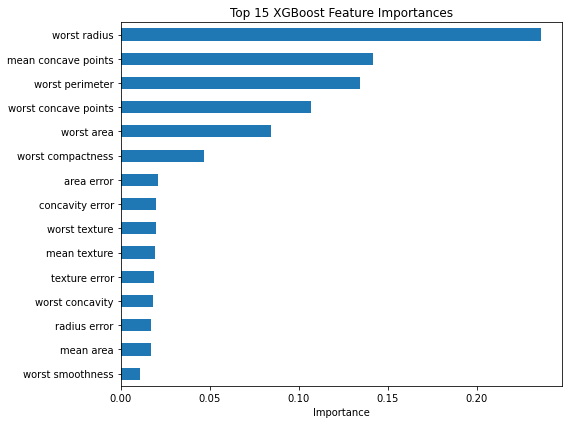

In [35]:
import matplotlib.pyplot as plt

importance.head(15).sort_values().plot(
    kind="barh",
    figsize=(8, 6)
)

plt.title("Top 15 XGBoost Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

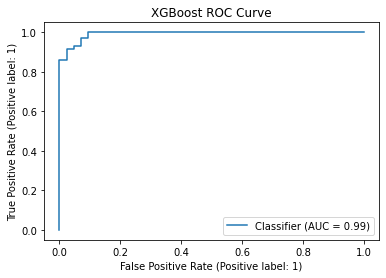

In [36]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    best_xgb_probabilities
)

plt.title("XGBoost ROC Curve")
plt.show()

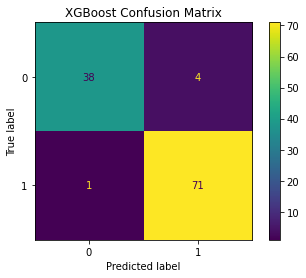

In [37]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_xgb_predictions
)

plt.title("XGBoost Confusion Matrix")
plt.show()

In [ ]:
# save the final model:
import joblib

joblib.dump(
    best_xgb,
    "xgboost_breast_cancer_model.pkl"
)

In [ ]:
# load it later:
loaded_model = joblib.load(
    "xgboost_breast_cancer_model.pkl"
)

In [ ]:
# prediction on unseen data
prediction = loaded_model.predict(
    X_test.iloc[[0]]
)

probability = loaded_model.predict_proba(
    X_test.iloc[[0]]
)[:, 1]

print("Prediction:", prediction)
print("Probability:", probability)

For Current XGBoost APIs, early stopping can be configured through the estimator's fit/training configuration depending on the installed XGBoost version.

A common pattern is:

In [ ]:
 xgb_model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    eval_metric="logloss",
    early_stopping_rounds=50
)

# Then provide an evaluation set:

xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

# However, don't use your final test set for early stopping in a proper production evaluation.
# Instead, create:
# Training
# Validation
# Test

# For example:
# 70% → training
# 15% → validation
# 15% → final test
# Then:

eval_set=[(X_validation, y_validation)]

# and keep the final test set completely untouched.